# Task 3 · Inverse PINN for hydraulic conductivity

## Objective

Estimate the homogeneous hydraulic conductivity $k$ from observed velocity magnitudes while retaining the physics learned by the data-free Task 2 forward PINN.

The workflow is

$$(\hat{x},\hat{y}) \longrightarrow H_\theta \longrightarrow |\nabla h_\theta| \longrightarrow v_{pred}=k|\nabla h_\theta|.$$

The 25-neuron × 6-hidden-layer forward network is initialized from the Adam + L-BFGS checkpoint. Task 3 then jointly refines its head weights and the positive learnable scalar $k$ using the original physics/boundary losses plus a strongly weighted observed-velocity loss. Reference head data are visualized for validation but never enter the training objective.

### 0. Importing libraries

In [98]:
%pip install -q numpy pandas matplotlib scipy openpyxl torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
from scipy.interpolate import griddata
from pathlib import Path

import torch
import torch.nn as nn
import random

# Cohesive presentation style used by every figure in this notebook.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10.5,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PRESENTATION_COLORS = {
    "navy": "#264653", "teal": "#2A9D8F", "gold": "#E9C46A",
    "orange": "#F4A261", "coral": "#E76F51",
}

In [100]:
# Set the same random seed for reproducible runs.
random.seed(1)
np.random.seed(1)
torch.manual_seed(1)

In [101]:
# Prefer CUDA, then Apple Metal (MPS), and otherwise use the CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. Reference head field

The spreadsheet provides coordinates and a reference hydraulic head field. These values help us understand the geometry and assess the forward solution visually; they do **not** enter the physics-informed training loss.

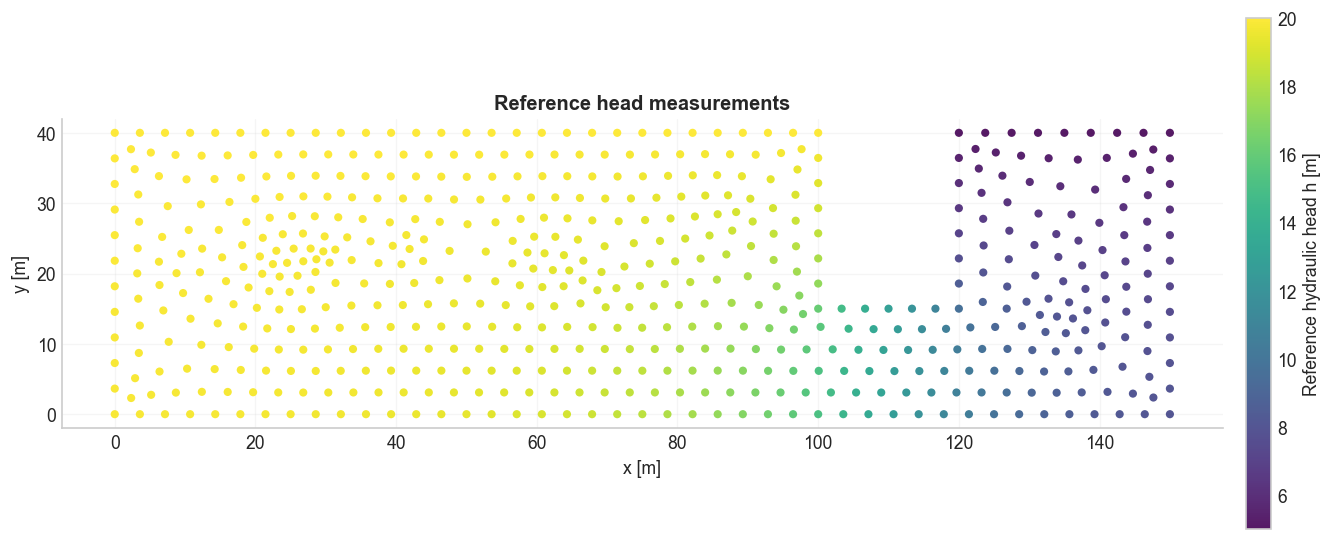

In [102]:
numericldata = pd.read_excel('../Data/heads/20_5_25.xlsx',header=0)
X = numericldata['X'].to_numpy()
Y = numericldata['Y'].to_numpy()
h = numericldata['FINIT'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 4.4), constrained_layout=True)
scatter = ax.scatter(
    X, Y, c=h, cmap="viridis", s=24, edgecolor="none", alpha=0.9
)
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Reference hydraulic head h [m]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="Reference head measurements")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.18)
plt.show()

## 2. Observed velocity field

The inverse information is the measured speed $v^*=|\mathbf v^*|$ at known physical coordinates. These observations are used only in Task 3 through the velocity mismatch $\mathcal L_v$. Because the file contains magnitudes rather than signed components, this notebook identifies one positive isotropic scalar conductivity.

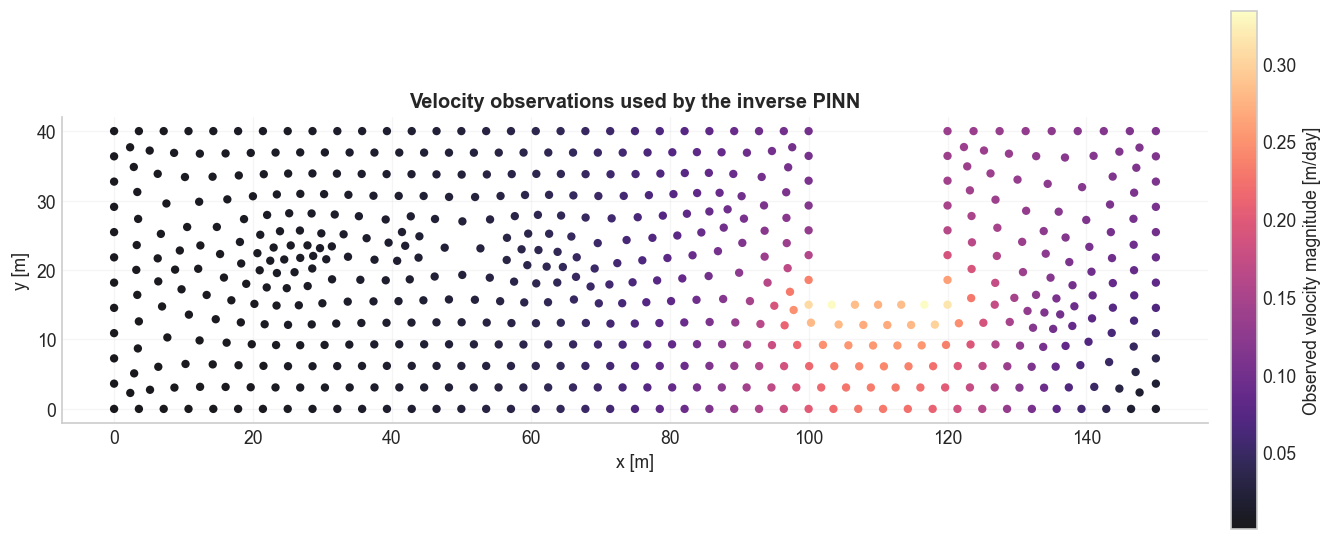

In [103]:
numeric_vel_ldata = pd.read_excel('../Data/velocities/20_5_25.xlsx',header=0)
v = numeric_vel_ldata['VINIT'].to_numpy()
X_v = numeric_vel_ldata['X'].to_numpy()
Y_v = numeric_vel_ldata['Y'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 4.4), constrained_layout=True)
scatter = ax.scatter(
    X_v, Y_v, c=v, cmap="magma", s=25, edgecolor="none", alpha=0.9
)
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Observed velocity magnitude [m/day]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="Velocity observations used by the inverse PINN")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.18)
plt.show()

## 3. Geometry and nondimensionalization

Coordinates and hydraulic head are nondimensionalized before they enter the neural network:

$$\hat{x}=x/L,\qquad \hat{y}=y/L,\qquad H=(h-h_2)/(h_1-h_2).$$

Consequently, the dimensional head gradient required by Darcy's law is

$$\nabla h=\frac{h_1-h_2}{L}\nabla_{\hat{x},\hat{y}}H.$$

### Physical parameters

The aquifer is a rectangle with an impermeable dam cutout. The upstream and downstream top segments have prescribed heads $h_1$ and $h_2$; the dam faces, dam base, aquifer base, and exterior side walls are no-flow boundaries.

In [104]:
# Geometry of problem
h1 = 20
h2 = 5
hd = 25

L = 150

y_top = 40 # top of aquifer
y_bot = 0  # bottom of aquifer
x_left = 0  # left boundary of aquifer
x_right = L   # right boundary of aquifer

x_dleft = 100   # left boundary of dam
x_dright = 120  # right boundary of dam
y_dbot = 40 - hd    # bottom of dam


In [105]:
def interpolate_head(X, Y, h, 
                     grid_res=(300, 100),
                     domain_bounds=(x_left, x_right, y_bot, y_top),
                     dam_bounds=(x_dleft, x_dright, y_dbot, y_top),
                     method="linear"):
    
    x_min, x_max, y_min, y_max = domain_bounds
    num_x, num_y = grid_res

    # Generate regular 2D grid
    xi = np.linspace(x_min, x_max, num_x)
    yi = np.linspace(y_min, y_max, num_y)
    grid_x, grid_y = np.meshgrid(xi, yi)

    # Interpolate scattered points
    grid_h = griddata((X,Y), h, (grid_x, grid_y), method=method)

    # Mask out dam region
    x_dl, x_dr, y_db, y_dt = dam_bounds
    dam_mask = (grid_x >= x_dl) & (grid_x <= x_dr) & (grid_y >= y_db) & (grid_y <= y_dt)
    # Replace all h values within the dam area with nan
    grid_h[dam_mask] = np.nan

    return grid_x, grid_y, grid_h

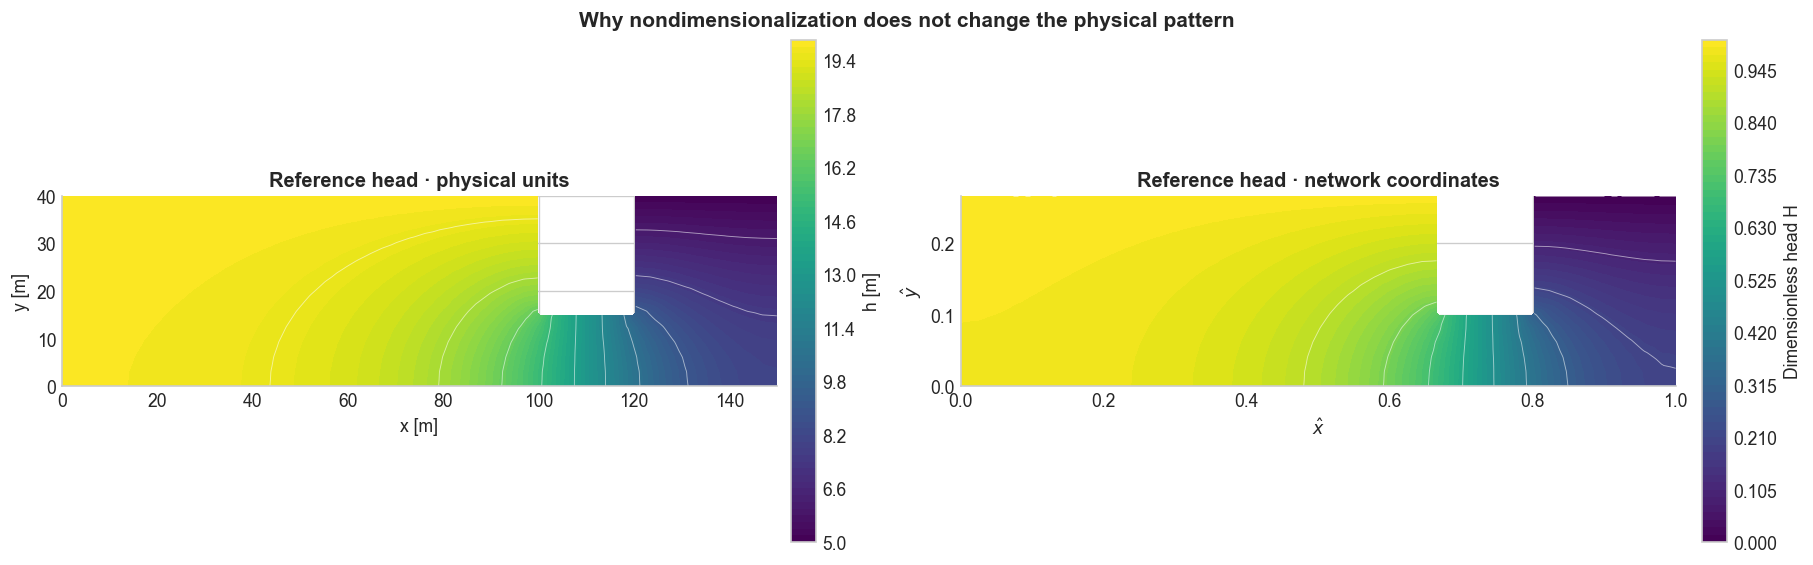

In [106]:
grid_X, grid_Y, grid_h = interpolate_head(X, Y, h)
def to_hat_xy(xy):
    """Convert dimensional coordinates [m] to nondimensional coordinates."""
    return xy / L

def to_hat_head(h):
    return (h-h2)/(h1-h2)

def from_hat_head(H):
    """Convert nondimensional head H back to dimensional head h [m]."""
    return h2 + (h1 - h2) * H

grid_X_hat, grid_Y_hat, grid_h_hat = to_hat_xy(grid_X), to_hat_xy(grid_Y), to_hat_head(grid_h)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
fields = [grid_h, grid_h_hat]
meshes = [(grid_X, grid_Y), (grid_X_hat, grid_Y_hat)]
titles = ["Reference head · physical units", "Reference head · network coordinates"]
labels = [("x [m]", "y [m]", "h [m]"),
          (r"$\hat{x}$", r"$\hat{y}$", "Dimensionless head H")]

for ax, field, (xm, ym), title, (xlabel, ylabel, cbar_label) in zip(
    axes, fields, meshes, titles, labels
):
    contour = ax.contourf(xm, ym, field, levels=80, cmap="viridis")
    ax.contour(xm, ym, field, levels=10, colors="white", linewidths=0.55, alpha=0.55)
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(contour, ax=ax, pad=0.02, label=cbar_label)
fig.suptitle("Why nondimensionalization does not change the physical pattern", fontweight="bold")
plt.show()

## 4. Computational domain and boundary map

Training points are sampled in nondimensional coordinates. Interior collocation points enforce Laplace's equation, while boundary points enforce either prescribed head or zero normal flux. Points inside the solid dam are rejected.

- Blue: upstream reservoir, $H=1$.
- Orange: downstream catchment, $H=0$.
- Red/dark blue: impermeable boundaries, $\nabla H\cdot\mathbf n=0$.
- Grey: interior PDE collocation points.

In [107]:
# normalise domain and dam bounds
# xmin, xmax, ymin, ymax
domain_bounds = np.array([x_left, x_right, y_bot, y_top])
dam_bounds = np.array([x_dleft, x_dright, y_dbot, y_top])

domain_bounds_norm = to_hat_xy(domain_bounds)
dam_bounds_norm = to_hat_xy(dam_bounds)

print(domain_bounds_norm)
print(dam_bounds_norm)

[0.         1.         0.         0.26666667]
[0.66666667 0.8        0.1        0.26666667]


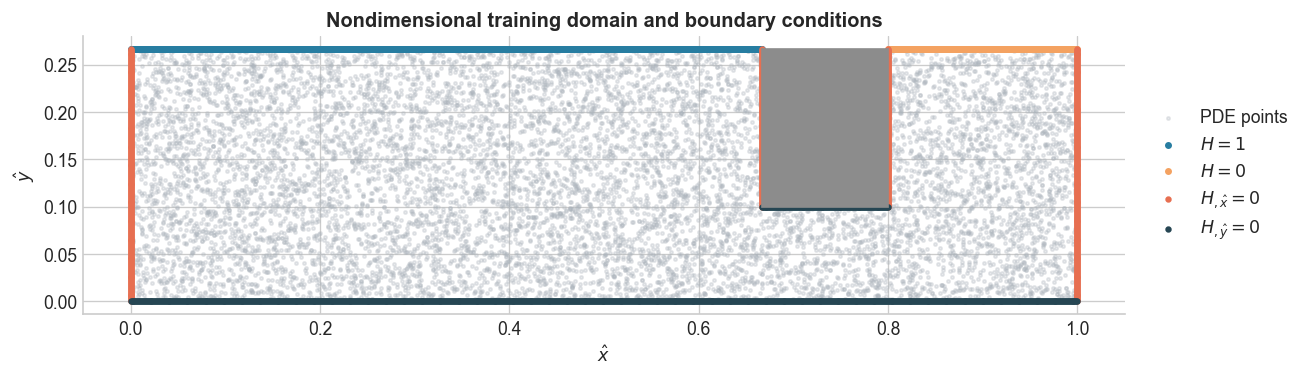

In [108]:
def sample_boundaries(n_density, domain_bounds, dam_bounds):
    """Sample all boundary segments in nondimensional coordinates."""
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds

    def count(length):
        return max(2, int(np.ceil(n_density * length)))

    x = np.linspace(x_l, x_dl, count(x_dl - x_l))
    bc_h1 = np.column_stack([x, np.full_like(x, y_t)])
    x = np.linspace(x_dr, x_r, count(x_r - x_dr))
    bc_h2 = np.column_stack([x, np.full_like(x, y_t)])

    y_dam = np.linspace(y_db, y_dt, count(y_dt - y_db))
    y_side = np.linspace(y_b, y_t, count(y_t - y_b))
    vertical = [
        np.column_stack([np.full_like(y_dam, x_dl), y_dam]),
        np.column_stack([np.full_like(y_dam, x_dr), y_dam]),
        np.column_stack([np.full_like(y_side, x_l), y_side]),
        np.column_stack([np.full_like(y_side, x_r), y_side]),
    ]

    x_bottom = np.linspace(x_l, x_r, count(x_r - x_l))
    x_dam_base = np.linspace(x_dl, x_dr, count(x_dr - x_dl))
    horizontal = [
        np.column_stack([x_bottom, np.full_like(x_bottom, y_b)]),
        np.column_stack([x_dam_base, np.full_like(x_dam_base, y_db)]),
    ]
    return {"h1": bc_h1, "h2": bc_h2, "vx0": np.vstack(vertical), "vy0": np.vstack(horizontal)}

def sample_interior_points(num_points, domain_bounds, dam_bounds, seed=1):
    """Sample PDE points in the aquifer while rejecting the solid dam."""
    rng = np.random.default_rng(seed)
    x_l, x_r, y_b, y_t = domain_bounds
    x_dl, x_dr, y_db, y_dt = dam_bounds
    accepted = []
    while sum(len(batch) for batch in accepted) < num_points:
        candidate = np.column_stack([rng.uniform(x_l, x_r, num_points), rng.uniform(y_b, y_t, num_points)])
        in_dam = ((candidate[:, 0] >= x_dl) & (candidate[:, 0] <= x_dr) &
                  (candidate[:, 1] >= y_db) & (candidate[:, 1] <= y_dt))
        accepted.append(candidate[~in_dam])
    return np.vstack(accepted)[:num_points]

bc_density = 1000
bc = sample_boundaries(bc_density, domain_bounds_norm, dam_bounds_norm)
xy_internal = sample_interior_points(10_000, domain_bounds_norm, dam_bounds_norm)
x_internal, y_internal = xy_internal[:, 0:1], xy_internal[:, 1:2]
x_bc_h1, y_bc_h1 = bc["h1"][:, 0:1], bc["h1"][:, 1:2]
x_bc_h2, y_bc_h2 = bc["h2"][:, 0:1], bc["h2"][:, 1:2]
x_bc_vx0, y_bc_vx0 = bc["vx0"][:, 0:1], bc["vx0"][:, 1:2]
x_bc_vy0, y_bc_vy0 = bc["vy0"][:, 0:1], bc["vy0"][:, 1:2]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(xy_internal[:, 0], xy_internal[:, 1], s=4, color="#ADB5BD", alpha=0.28, label="PDE points")
ax.scatter(*bc["h1"].T, s=10, color="#277DA1", label=r"$H=1$")
ax.scatter(*bc["h2"].T, s=10, color="#F4A261", label=r"$H=0$")
ax.scatter(*bc["vx0"].T, s=8, color="#E76F51", label=r"$H_{,\hat{x}}=0$")
ax.scatter(*bc["vy0"].T, s=8, color="#264653", label=r"$H_{,\hat{y}}=0$")
ax.fill([x_dleft/L, x_dright/L, x_dright/L, x_dleft/L], [y_dbot/L, y_dbot/L, y_top/L, y_top/L], color="0.55", zorder=5)
ax.set(xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$", title="Nondimensional training domain and boundary conditions")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## 5. Physics-informed loss functions

Our model receives non-dimensional coordinates and predicts non-dimensional head:

$$
(\hat{x}, \hat{y}) \mapsto H_\theta(\hat{x}, \hat{y}).
$$

Automatic differentiation provides the first and second derivatives of $H_\theta$. The forward model is trained without head measurements using three physical objectives:

$$\mathcal L_{PDE}=\operatorname{MSE}(H_{,\hat{x}\hat{x}}+H_{,\hat{y}\hat{y}},0),$$

$$\mathcal L_D=\operatorname{MSE}(H,1)_{upstream}+\operatorname{MSE}(H,0)_{downstream},$$

$$\mathcal L_N=\operatorname{MSE}(\nabla H\cdot\mathbf n,0)_{impermeable}.$$

The derivative boundary terms correspond to zero normal water flux through the aquifer walls and dam surfaces.

In [109]:
# when head must have a specfic numerical value at boundary
def loss_bc_value(model, x, y, val):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)

    bc_real = torch.full_like(H, val, device=device)
    bc_loss = torch.mean((H - bc_real)**2)
    return bc_loss

# when one of the derivatives must vanish
# dim = 0 or 1 (x or y)
def loss_bc_grad(model, x, y, dim):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    
    u = x if dim==0 else y
    H_u = torch.autograd.grad(H, u,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    
    # derivative should vanish, so nonzero value is taken as loss
    bc_loss = torch.mean((H_u)**2)
    return bc_loss

# PDE loss, from LaPlace equation
def loss_pde(model, x, y):
    x = torch.tensor(x, dtype=torch.float32, requires_grad=True, device=device)
    y = torch.tensor(y, dtype=torch.float32, requires_grad=True, device=device)

    input = torch.cat((x,y), dim=1)
    H = model(input)
    H_x = torch.autograd.grad(H, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_xx = torch.autograd.grad(H_x, x,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_y = torch.autograd.grad(H, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]
    H_yy = torch.autograd.grad(H_y, y,
                              grad_outputs=torch.ones_like(H),
                              create_graph=True)[0]

    pde_residual = H_xx + H_yy
    return torch.mean(pde_residual**2)


# when y derivative of head must vanish



## 6. Task 2 physics retained by the inverse PINN

### Physics and boundary part of the Task 3 objective

The network maps nondimensional coordinates to nondimensional head:

$$ (\hat{x},\hat{y}) \mapsto H_\theta(\hat{x},\hat{y}). $$

The grouped loss is

$$ \mathcal{L}=\mathcal{L}_{PDE}+\lambda_D\mathcal{L}_D+\lambda_N\mathcal{L}_N, $$

where

$$ \mathcal{L}_{PDE}=\operatorname{MSE}(H_{,\hat{x}\hat{x}}+H_{,\hat{y}\hat{y}},0), $$

$$ \mathcal{L}_D=\operatorname{MSE}(H,1)_{reservoir}+\operatorname{MSE}(H,0)_{catchment}, $$

$$ \mathcal{L}_N=\operatorname{MSE}(H_{,\hat{x}},0)_{vertical}+\operatorname{MSE}(H_{,\hat{y}},0)_{horizontal}. $$

These are the Task 2 loss components reused directly by the single Task 3 model. The 25×6 Adam + L-BFGS checkpoint supplies the initialization; Task 3 adds the observed-velocity loss and jointly refines the head weights and $k$. Reference-head observations are never included in training.

### Multilayer perceptron

The `MLP` maps two nondimensional coordinates to one nondimensional head value. Smooth `tanh` activations are used because the PDE loss requires stable first and second derivatives.

In [110]:
class MLP(nn.Module):
    # arch = [inputs] + [hidden neurons]*number + [outputs]
    def __init__(self, arch, act):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(arch) - 1):
            layers.append(nn.Linear(arch[i], arch[i + 1]))
            if i < len(arch) - 2:
                layers.append(act())
        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        out = self.model(inputs)
        return out

In [111]:
def predict_head_grid(model, nx=300, ny=100):
    """Evaluate dimensionless H on the aquifer grid and return dimensional h."""
    x_grid = np.linspace(x_left, x_right, nx)
    y_grid = np.linspace(y_bot, y_top, ny)
    x_mesh, y_mesh = np.meshgrid(x_grid, y_grid, indexing="xy")
    xy_dim = np.column_stack([x_mesh.ravel(), y_mesh.ravel()])
    xy_hat = to_hat_xy(xy_dim)

    model.eval()
    with torch.no_grad():
        H_pred = model(torch.as_tensor(xy_hat, dtype=torch.float32, device=device))

    H_pred = H_pred.detach().cpu().numpy().reshape(y_mesh.shape)
    h_pred = from_hat_head(H_pred)
    dam_mask = ((x_mesh >= x_dleft) & (x_mesh <= x_dright) &
                (y_mesh >= y_dbot) & (y_mesh <= y_top))
    return x_mesh, y_mesh, np.ma.masked_where(dam_mask, h_pred)

def plot_head_prediction(model, title, nx=300, ny=100):
    """Plot predicted dimensional head on physical coordinates."""
    x_mesh, y_mesh, h_pred = predict_head_grid(model, nx=nx, ny=ny)

    fig, ax = plt.subplots(figsize=(10, 4))
    levels = np.linspace(h2, h1, 101)
    contour = ax.contourf(
        x_mesh, y_mesh, h_pred, levels=levels, cmap="viridis", extend="both"
    )
    ax.contour(
        x_mesh, y_mesh, h_pred, levels=np.linspace(h2, h1, 11),
        colors="white", linewidths=0.6, alpha=0.55
    )
    ax.fill(
        [x_dleft, x_dright, x_dright, x_dleft],
        [y_dbot, y_dbot, y_top, y_top],
        color="0.6", label="impermeable dam"
    )

    
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label("Predicted hydraulic head h [m]")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bot, y_top)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()
    return fig, ax, h_pred



### 7. Train an inverse PINN to estimate hydraulic conductivity

Task 3 reuses the data-free forward PINN trained in Task 2. Its 25-neuron, 6-hidden-layer MLP weights are loaded from the Adam + L-BFGS checkpoint as a physics-informed initialization. We then build **one joint inverse PINN** containing this head network and hydraulic conductivity $k$ as a positive learnable `nn.Parameter`. During Task 3, both the head-network weights and $k$ are optimized together while retaining all Task 2 physics and boundary losses.

This is an inverse PINN because the differentiable head field continues to satisfy the governing equation and boundary conditions, while the additional observed-velocity term identifies the unknown material parameter.

### Prepare the inverse data

1. Read the measured speed $s_i=|\mathbf v_i|$ and its physical coordinate $(x_i,y_i)$.
2. Remove missing measurements and points inside the solid dam.
3. Convert coordinates to $(\hat{x}_i,\hat{y}_i)=(x_i/L,y_i/L)$ because that is what the trained head network expects.
4. Rebuild the Task 2 MLP as `[2] + [25] * 6 + [1]` and initialize it from `adam+lbfgs.pt`.
5. Keep velocity in dimensional units of m/day.

Loaded Task 2 forward weights: /Users/alenaweber/Documents/RWTH/Semester 4/Physics informed Modelling in Geomechanics/Dam Flow/PIIM/Results/weights_20260724_111937/adam+lbfgs.pt
Task 2 architecture: [2, 25, 25, 25, 25, 25, 25, 1]


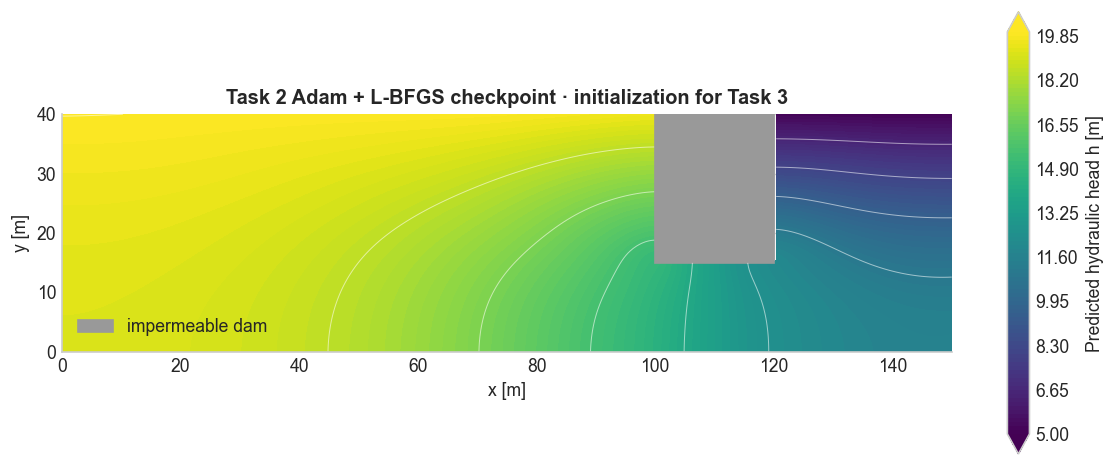

(<Figure size 1200x480 with 2 Axes>,
 <Axes: title={'center': 'Task 2 Adam + L-BFGS checkpoint · initialization for Task 3'}, xlabel='x [m]', ylabel='y [m]'>,
 masked_array(
   data=[[19.229951858520508, 19.229778289794922, 19.229503631591797, ...,
          11.635171890258789, 11.63770866394043, 11.640716552734375],
         [19.23009490966797, 19.22993278503418, 19.229665756225586, ...,
          11.632162094116211, 11.634641647338867, 11.637592315673828],
         [19.230396270751953, 19.23024559020996, 19.22998046875, ...,
          11.628412246704102, 11.630827903747559, 11.633711814880371],
         ...,
         [19.984050750732422, 19.983869552612305, 19.983657836914062, ...,
          5.330866813659668, 5.333127021789551, 5.335664749145508],
         [19.997190475463867, 19.996986389160156, 19.996749877929688, ...,
          5.219206809997559, 5.221736431121826, 5.224533557891846],
         [20.010345458984375, 20.010112762451172, 20.009849548339844, ...,
          5.107642650

In [112]:
# Extract observed velocity magnitudes and their coordinates.
vel_xy = numeric_vel_ldata[["X", "Y"]].to_numpy(dtype=float)
vel_obs = numeric_vel_ldata["VINIT"].to_numpy(dtype=float).reshape(-1, 1)

# Remove missing rows and any accidental point inside the solid dam.
inside_dam = ((vel_xy[:, 0] > x_dleft) & (vel_xy[:, 0] < x_dright) &
              (vel_xy[:, 1] > y_dbot) & (vel_xy[:, 1] <= y_top))
valid_vel = np.isfinite(vel_xy).all(axis=1) & np.isfinite(vel_obs).ravel() & ~inside_dam
vel_xy_hat = to_hat_xy(vel_xy[valid_vel])
vel_obs = vel_obs[valid_vel]

# Rebuild the exact Task 2 forward architecture: 2 inputs, 6 x 25 tanh layers, 1 head output.
task2_architecture = [2] + [25] * 6 + [1]
head_model = MLP(task2_architecture, nn.Tanh).to(device)

# Locate the Adam + L-BFGS Task 2 checkpoint from either PIIM/ or PIIM/Code/.
working_dir = Path.cwd().resolve()
project_root = working_dir if (working_dir / "Results").is_dir() else working_dir.parent
checkpoint_candidates = sorted(
    (project_root / "Results").glob("weights_*/adam+lbfgs.pt"),
    key=lambda path: path.parent.name,
)
if not checkpoint_candidates:
    raise FileNotFoundError(
        "No Results/weights_*/adam+lbfgs.pt checkpoint was found. "
        "Run and save the Task 2 Adam + L-BFGS forward model first."
    )
task2_checkpoint = checkpoint_candidates[-1]
checkpoint_state = torch.load(task2_checkpoint, map_location=device, weights_only=True)
head_model.load_state_dict(checkpoint_state, strict=True)
head_model.eval()
print(f"Loaded Task 2 forward weights: {task2_checkpoint}")
print(f"Task 2 architecture: {task2_architecture}")

# The checkpoint initializes Task 3. Its head weights remain trainable in the joint inverse PINN.
for parameter in head_model.parameters():
    parameter.requires_grad_(True)

# Visualize the Task 2 initialization before joint inverse refinement.
plot_head_prediction(
    head_model,
    "Task 2 Adam + L-BFGS checkpoint · initialization for Task 3",
)

### Learn `k` from the velocity loss

For homogeneous isotropic material, Darcy's law is

$$\mathbf v=-k\nabla h. $$

Because the spreadsheet contains velocity magnitude rather than signed components, define

$$s_i=|\mathbf v_i|, \qquad g_i=|\nabla h_\theta(x_i,y_i)|. $$

Then $s_i\approx k g_i$. The inverse model represents the conductivity by

$$k=\operatorname{softplus}(k_{raw})+\varepsilon,$$

so it remains positive during training. Its observed-velocity boundary/data loss is

$$\boxed{\mathcal L_v=\operatorname{MSE}(v_\theta,v^*)
=\frac{1}{N}\sum_{i=1}^N\left(k|\nabla h_\theta(x_i,y_i)|- v_{real}\right)^2}. $$

Task 3 adds this term to the original Task 2 losses:

$$\boxed{\mathcal L_{inverse}=\mathcal L_{PDE}+\lambda_D\mathcal L_D+\lambda_N\mathcal L_N+\lambda_v\mathcal L_v}.$$

A deliberately large $\lambda_v$ makes agreement with observed speed influential relative to the PDE and boundary terms. Adam updates the head-network weights and $k_{raw}$ together, so `k` is learned inside one joint inverse model rather than calculated in post-processing.

In [113]:
class InverseDarcyPINN(nn.Module):
    """One joint model for head H(x,y), velocity, and positive conductivity k."""
    def __init__(self, head_model, initial_k=0.5):
        super().__init__()
        self.head_model = head_model
        if initial_k <= 0:
            raise ValueError("initial_k must be positive.")
        # Inverse softplus gives k=initial_k at initialization.
        initial_raw_k = np.log(np.expm1(initial_k))
        self.raw_k = nn.Parameter(torch.tensor(initial_raw_k, dtype=torch.float32))

    @property
    def k(self):
        return torch.nn.functional.softplus(self.raw_k) + 1.0e-8

    def forward(self, xy_hat):
        """Predict nondimensional hydraulic head H."""
        return self.head_model(xy_hat)

    def predict_speed(self, xy_hat):
        """Predict dimensional Darcy speed while retaining gradients for joint training."""
        if not torch.is_tensor(xy_hat):
            xy_hat = torch.as_tensor(xy_hat, dtype=torch.float32, device=device)
        xy_hat = xy_hat.detach().clone().requires_grad_(True)
        H = self.forward(xy_hat)
        grad_H = torch.autograd.grad(
            H, xy_hat, grad_outputs=torch.ones_like(H), create_graph=True
        )[0]
        grad_h = ((h1 - h2) / L) * grad_H
        gradient_factor = torch.linalg.vector_norm(grad_h, dim=1, keepdim=True)
        return self.k * gradient_factor, grad_h, gradient_factor


def velocity_data_loss(predicted_velocity, observed_velocity):
    """Observed-velocity loss L_v = MSE(v_theta - v*)."""
    return torch.mean((predicted_velocity - observed_velocity) ** 2)


# Build one joint inverse model and prepare the observed velocities.
inverse_model = InverseDarcyPINN(head_model, initial_k=0.5).to(device)
velocity_xy_tensor = torch.as_tensor(vel_xy_hat, dtype=torch.float32, device=device)
velocity_target = torch.as_tensor(vel_obs, dtype=torch.float32, device=device)

# Joint Task 3 objective: retain Task 2 physics and strongly enforce measured velocity.
lambda_D = 30.0
lambda_N = 5.0
lambda_velocity = 100.0
inverse_epochs = 2000
inverse_optimizer = torch.optim.Adam(inverse_model.parameters(), lr=1.0e-3)
inverse_history = {
    "total": [], "pde": [], "dirichlet": [], "neumann": [],
    "velocity": [], "weighted_velocity": [], "k": [],
}

for epoch in range(inverse_epochs):
    inverse_optimizer.zero_grad()

    # Original Task 2 physics and boundary-condition losses.
    pde_loss = loss_pde(inverse_model, x_internal, y_internal)
    bc_h1_loss = loss_bc_value(inverse_model, bc["h1"][:, 0:1], bc["h1"][:, 1:2], 1.0)
    bc_h2_loss = loss_bc_value(inverse_model, bc["h2"][:, 0:1], bc["h2"][:, 1:2], 0.0)
    bc_vx0_loss = loss_bc_grad(inverse_model, bc["vx0"][:, 0:1], bc["vx0"][:, 1:2], dim=0)
    bc_vy0_loss = loss_bc_grad(inverse_model, bc["vy0"][:, 0:1], bc["vy0"][:, 1:2], dim=1)
    dirichlet_loss = bc_h1_loss + bc_h2_loss
    neumann_loss = bc_vx0_loss + bc_vy0_loss

    # New inverse-data term: L_v = MSE(v_pred, v_observed).
    velocity_prediction, _, _ = inverse_model.predict_speed(velocity_xy_tensor)
    loss_velocity = velocity_data_loss(velocity_prediction, velocity_target)
    weighted_velocity_loss = lambda_velocity * loss_velocity

    inverse_loss = (
        pde_loss
        + lambda_D * dirichlet_loss
        + lambda_N * neumann_loss
        + weighted_velocity_loss
    )
    inverse_loss.backward()
    inverse_optimizer.step()

    inverse_history["total"].append(float(inverse_loss.detach().cpu()))
    inverse_history["pde"].append(float(pde_loss.detach().cpu()))
    inverse_history["dirichlet"].append(float(dirichlet_loss.detach().cpu()))
    inverse_history["neumann"].append(float(neumann_loss.detach().cpu()))
    inverse_history["velocity"].append(float(loss_velocity.detach().cpu()))
    inverse_history["weighted_velocity"].append(float(weighted_velocity_loss.detach().cpu()))
    inverse_history["k"].append(float(inverse_model.k.detach().cpu()))

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | total={inverse_loss.item():.3e} | "
            f"PDE={pde_loss.item():.3e} | D={dirichlet_loss.item():.3e} | "
            f"N={neumann_loss.item():.3e} | lambda_v*L_v={weighted_velocity_loss.item():.3e} | "
            f"k={inverse_model.k.item():.4e}"
        )

k_est = float(inverse_model.k.detach().cpu())
inverse_model.eval()
vel_pred_tensor, grad_h_tensor, factor_tensor = inverse_model.predict_speed(velocity_xy_tensor)
vel_pred = vel_pred_tensor.detach().cpu().numpy()
grad_h = grad_h_tensor.detach().cpu().numpy()
factor = factor_tensor.detach().cpu().numpy()

# Report how well the estimated k reproduces the observed velocity magnitudes.
velocity_rmse = float(np.sqrt(np.mean((vel_pred - vel_obs)**2)))
velocity_mae = float(np.mean(np.abs(vel_pred - vel_obs)))
velocity_range = float(vel_obs.max() - vel_obs.min())
metric_tolerance = np.sqrt(np.finfo(float).eps) * max(1.0, float(np.max(np.abs(vel_obs))))
velocity_rmse_percent = 100.0 * velocity_rmse / velocity_range if velocity_range > metric_tolerance else np.nan
velocity_mae_percent = 100.0 * velocity_mae / velocity_range if velocity_range > metric_tolerance else np.nan
ss_res = float(np.sum((vel_pred - vel_obs)**2))
ss_tot = float(np.sum((vel_obs - vel_obs.mean())**2))
velocity_r2 = 1.0 - ss_res / ss_tot if ss_tot > len(vel_obs) * metric_tolerance**2 else np.nan

print(f"Learned hydraulic conductivity k = {k_est:.4e} m/day")
print(f"Velocity weight lambda_v = {lambda_velocity:g}")
print(f"Final raw velocity MSE = {inverse_history['velocity'][-1]:.4e}")
print(f"Final weighted velocity loss = {inverse_history['weighted_velocity'][-1]:.4e}")
print(f"Final joint inverse loss = {inverse_history['total'][-1]:.4e}")
print(f"Velocity RMSE = {velocity_rmse:.4e} m/day")
print(f"Velocity MAE  = {velocity_mae:.4e} m/day")
print(f"Normalized RMSE = {velocity_rmse_percent:.2f}%")
print(f"Normalized MAE  = {velocity_mae_percent:.2f}%")
print(f"Velocity R² = {velocity_r2:.4f}")

Epoch    0 | total=7.627e+01 | PDE=7.571e+01 | D=1.940e-04 | N=3.073e-02 | lambda_v*L_v=4.056e-01 | k=5.0039e-01
Epoch  100 | total=4.318e+00 | PDE=2.035e+00 | D=1.724e-02 | N=2.861e-01 | lambda_v*L_v=3.356e-01 | k=5.4214e-01
Epoch  200 | total=3.228e+00 | PDE=1.189e+00 | D=1.174e-02 | N=2.809e-01 | lambda_v*L_v=2.815e-01 | k=5.8568e-01
Epoch  300 | total=2.817e+00 | PDE=8.405e-01 | D=1.079e-02 | N=2.819e-01 | lambda_v*L_v=2.428e-01 | k=6.3063e-01
Epoch  400 | total=2.576e+00 | PDE=6.472e-01 | D=1.019e-02 | N=2.831e-01 | lambda_v*L_v=2.072e-01 | k=6.7656e-01
Epoch  500 | total=2.413e+00 | PDE=5.261e-01 | D=9.741e-03 | N=2.841e-01 | lambda_v*L_v=1.747e-01 | k=7.2291e-01
Epoch  600 | total=2.294e+00 | PDE=4.436e-01 | D=9.406e-03 | N=2.846e-01 | lambda_v*L_v=1.458e-01 | k=7.6898e-01
Epoch  700 | total=2.202e+00 | PDE=3.841e-01 | D=9.174e-03 | N=2.844e-01 | lambda_v*L_v=1.208e-01 | k=8.1405e-01
Epoch  800 | total=2.128e+00 | PDE=3.390e-01 | D=9.030e-03 | N=2.837e-01 | lambda_v*L_v=1.000e-0

### Presentation figure · inverse training and velocity agreement

This three-panel figure answers three separate questions:

1. **Did the inverse optimization converge?** The velocity loss should decrease and $k$ should approach a stable plateau.
2. **Does the learned model reproduce the measurements?** Predictions should lie near the dashed 1:1 line.
3. **Is there systematic bias?** Residuals should be narrow and centered around zero.

RMSE and MAE are normalized by the observed velocity range and shown as percentages when that range is nonzero.

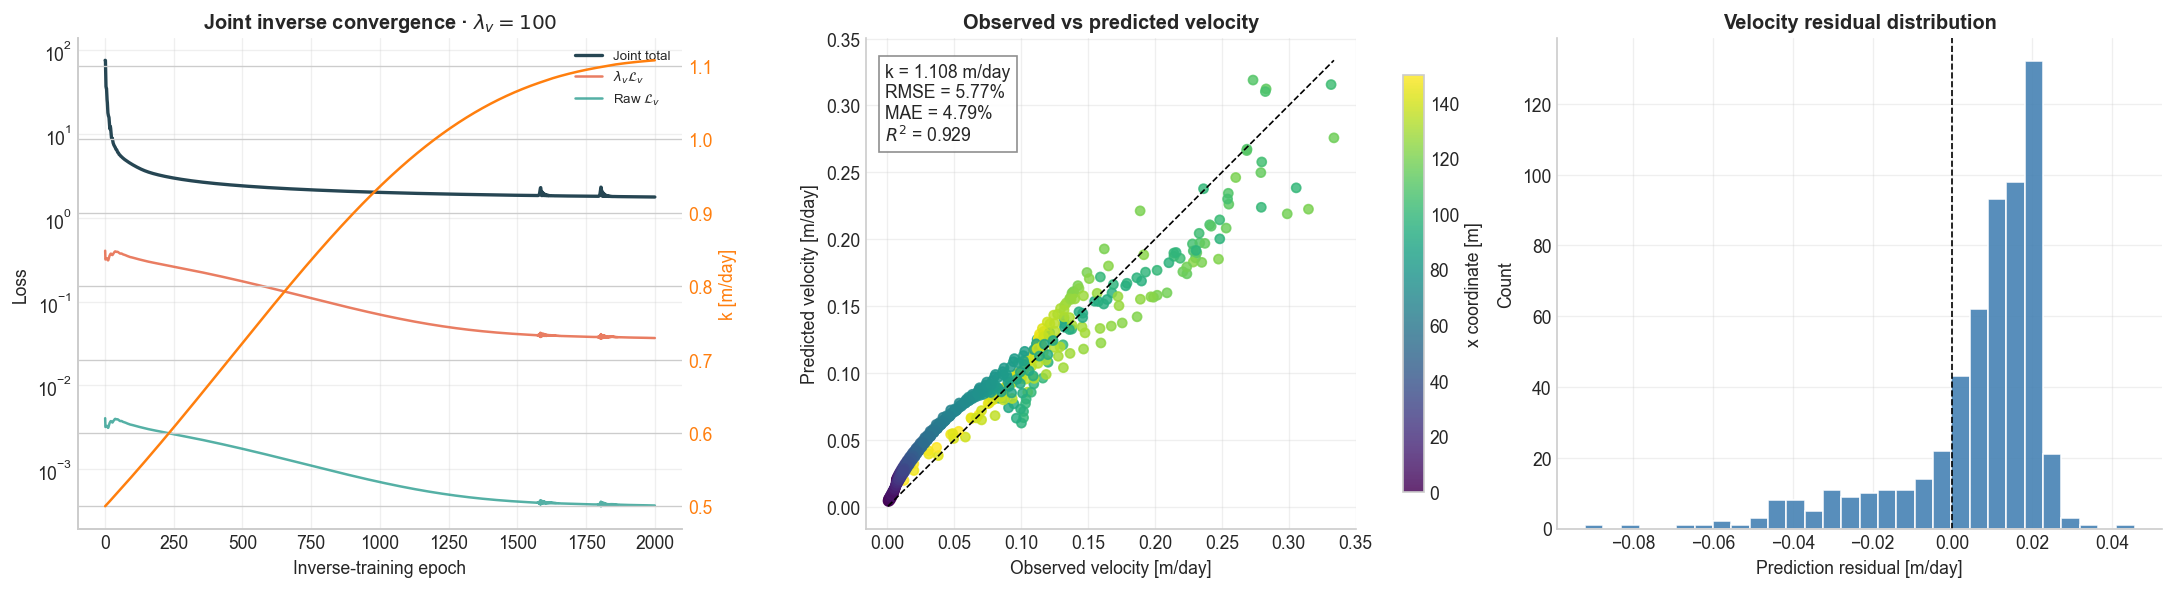

In [114]:
# Figure 3A: inverse-training and global fit diagnostics.
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

obs = vel_obs.ravel()
pred = vel_pred.ravel()
residual = pred - obs
vmin = min(obs.min(), pred.min())
vmax = max(obs.max(), pred.max())

epochs_inverse = np.arange(1, len(inverse_history["total"]) + 1)
axes[0].semilogy(epochs_inverse, inverse_history["total"], color="#264653", lw=2, label="Joint total")
axes[0].semilogy(epochs_inverse, inverse_history["weighted_velocity"], color="#E76F51", alpha=0.9, label=r"$\lambda_v\mathcal{L}_v$")
axes[0].semilogy(epochs_inverse, inverse_history["velocity"], color="#2A9D8F", alpha=0.8, label=r"Raw $\mathcal{L}_v$")
axes[0].set_xlabel("Inverse-training epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(rf"Joint inverse convergence · $\lambda_v={lambda_velocity:g}$")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)
k_axis = axes[0].twinx()
k_axis.plot(epochs_inverse, inverse_history["k"], color="tab:orange")
k_axis.set_ylabel("k [m/day]", color="tab:orange")
k_axis.tick_params(axis="y", labelcolor="tab:orange")

sc = axes[1].scatter(obs, pred, c=vel_xy[valid_vel, 0], cmap="viridis", s=30, alpha=0.82)
axes[1].plot([vmin, vmax], [vmin, vmax], "k--", linewidth=1)
axes[1].set_xlabel("Observed velocity [m/day]")
axes[1].set_ylabel("Predicted velocity [m/day]")
axes[1].set_title("Observed vs predicted velocity")
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[1], label="x coordinate [m]", shrink=0.85)
axes[1].text(
    0.04, 0.95,
    f"k = {k_est:.4g} m/day\nRMSE = {velocity_rmse_percent:.2f}%\nMAE = {velocity_mae_percent:.2f}%\n$R^2$ = {velocity_r2:.3f}",
    transform=axes[1].transAxes, va="top",
    bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "0.5"},
)

axes[2].hist(residual, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xlabel("Prediction residual [m/day]")
axes[2].set_ylabel("Count")
axes[2].set_title("Velocity residual distribution")
axes[2].grid(True, alpha=0.3)

plt.show()

### Presentation figure · spatial inverse diagnostics

The following figure shows each step spatially: the gradient magnitude supplied by the jointly trained head PINN, the measured speed, the reconstructed speed $k|\nabla h|$ from the inverse model, and the signed reconstruction residual.

A spatially random residual pattern supports the assumption of one homogeneous scalar $k$. Coherent positive or negative regions may instead indicate heterogeneous conductivity, directional anisotropy, measurement bias, or forward-head error.

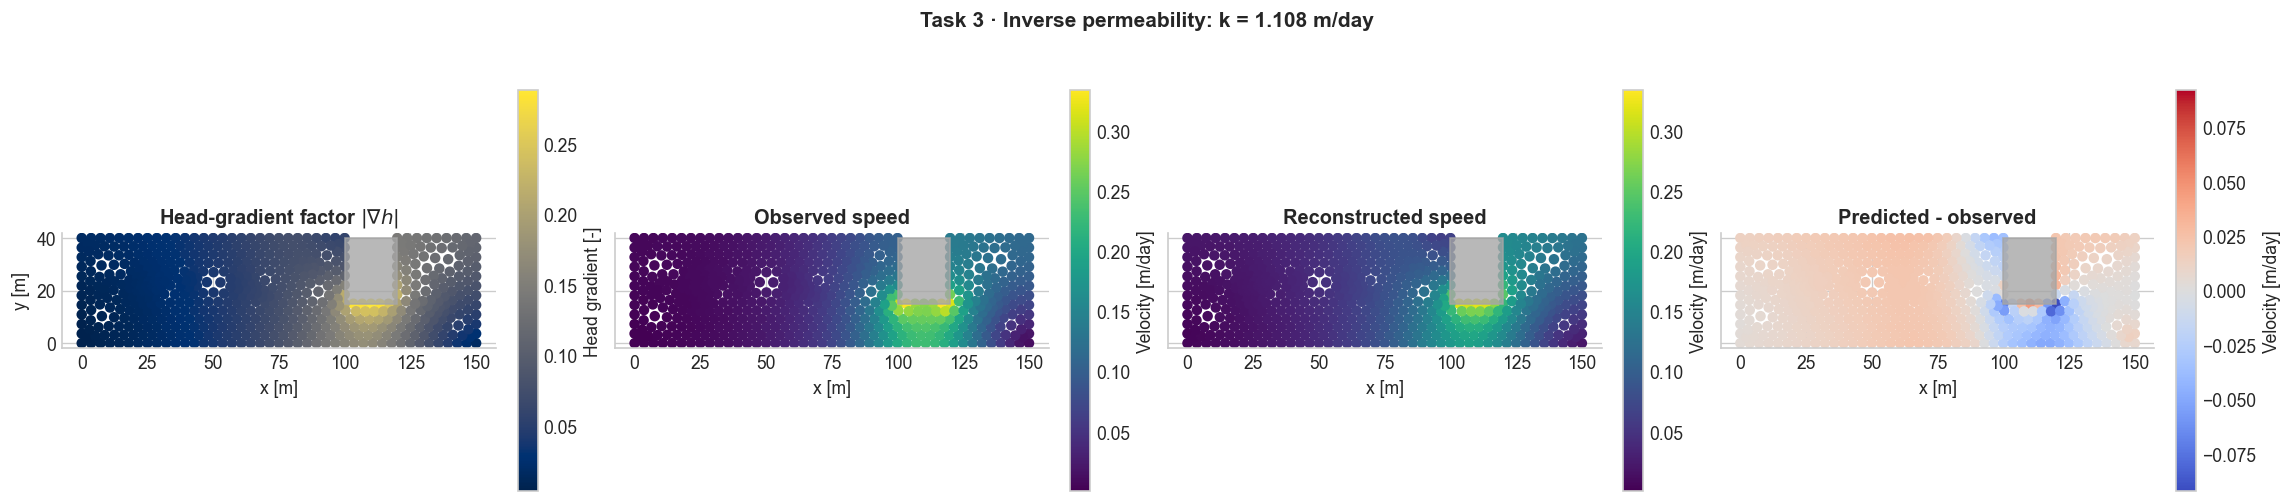

In [115]:
# Figure 3B: spatial maps of every inverse step.
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), sharex=True, sharey=True, constrained_layout=True)
plot_data = [factor.ravel(), obs, pred, residual]
titles = [r"Head-gradient factor $|\nabla h|$", "Observed speed", "Reconstructed speed", "Predicted - observed"]
cmaps = ["cividis", "viridis", "viridis", "coolwarm"]

abs_res = max(abs(residual.min()), abs(residual.max()))
limits = [(factor.min(), factor.max()), (obs.min(), obs.max()), (obs.min(), obs.max()), (-abs_res, abs_res)]

for ax, values, title, cmap, (lo, hi) in zip(axes, plot_data, titles, cmaps, limits):
    norm = TwoSlopeNorm(vmin=lo, vcenter=0.0, vmax=hi) if cmap == "coolwarm" and abs_res > 0 else None
    sc = ax.scatter(
        vel_xy[valid_vel, 0], vel_xy[valid_vel, 1],
        c=values, cmap=cmap, s=28, vmin=None if norm else lo, vmax=None if norm else hi, norm=norm
    )
    ax.fill(
        [x_dleft, x_dright, x_dright, x_dleft],
        [y_dbot, y_dbot, y_top, y_top],
        color="0.65", alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_aspect("equal", adjustable="box")
    label = "Head gradient [-]" if title.startswith("Head") else "Velocity [m/day]"
    fig.colorbar(sc, ax=ax, shrink=0.8, label=label)

axes[0].set_ylabel("y [m]")
fig.suptitle(f"Task 3 · Inverse permeability: k = {k_est:.4g} m/day", fontweight="bold")
plt.show()